In [76]:
!pip install matplotlib
import math
import matplotlib.pyplot as plt
import numpy as np
from sympy import symbols, diff, sin

Defaulting to user installation because normal site-packages is not writeable


## Bisection

**Characteristics:** Brackets the root between a lower and upper limit where the function changes sign, then repeatedly halves the interval. Guaranteed linear convergence — always converges if the initial bracket is valid. Only needs function evaluations (no derivative).

**Limitations:** Requires an initial interval `[a, b]` with `f(a)` and `f(b)` of opposite sign. Slow: convergence is linear, so tight precision can take many iterations. Cannot find roots of even multiplicity where the function doesn't cross zero.

**Best use:** A reliable bracket is known and robustness matters more than speed.

**Worst use:** High precision is needed quickly, or only a single initial guess (no bracket) is available.

Iteration: 0
	Lower Limit: 5.00000e-01, Upper Limit: 1.00000e+00, Mid Point: 0.00000e+00
	Function at Lower Limit: 0.00000e+00,Function at Upper Limit: 0.00000e+00, Function at Mid Point: 0.00000e+00
	Relative Error: 0.00000e+00
Iteration: 1
	Lower Limit: 5.00000e-01, Upper Limit: 7.50000e-01, Mid Point: 7.50000e-01
	Function at Lower Limit: 6.25000e-01,Function at Upper Limit: -3.00000e+00, Function at Mid Point: -1.32812e+00
	Relative Error: 0.00000e+00
Iteration: 2
	Lower Limit: 5.00000e-01, Upper Limit: 6.25000e-01, Mid Point: 6.25000e-01
	Function at Lower Limit: 6.25000e-01,Function at Upper Limit: -1.32812e+00, Function at Mid Point: -3.80859e-01
	Relative Error: 2.00000e-01
Iteration: 3
	Lower Limit: 5.62500e-01, Upper Limit: 6.25000e-01, Mid Point: 5.62500e-01
	Function at Lower Limit: 6.25000e-01,Function at Upper Limit: -3.80859e-01, Function at Mid Point: 1.15479e-01
	Relative Error: 1.11111e-01
Iteration: 4
	Lower Limit: 5.62500e-01, Upper Limit: 5.93750e-01, Mid Point: 5.

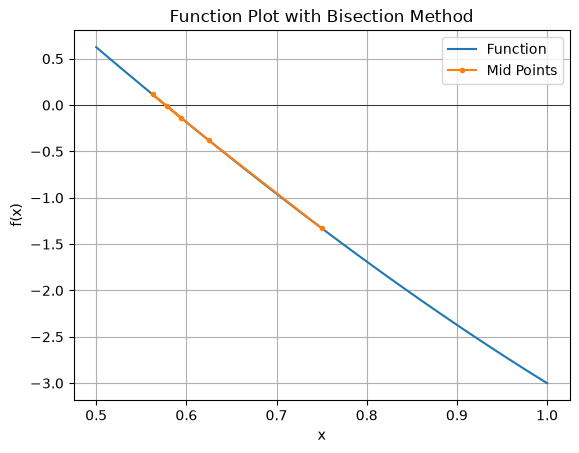

In [77]:
def Bisection( maxIterations: int , lowerLimit: float , upperLimit: float , precision: float , function: callable, verbose: bool = False, plotting = False ) -> float:
    if plotting:
        midPoints = []
        x = np.linspace(lowerLimit, upperLimit, 100)
        y = function(x)
        plt.plot(x, y, label='Function')
        plt.axhline(0, color='black', lw=0.5)
        plt.title('Function Plot with Bisection Method')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        

    iteration: int = 0
    midPoint: float = 0.0
    previusMidPoint: float = 0.0
    functionAplicationLowerLimit: float = 0.0
    functionAplicationUpperLimit: float = 0.0
    functionAplicationMidPoint: float = 0.0
    relativeError: float = 0.0
    ans: float = 0.0

    if verbose:
        print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e},Function at Upper Limit: {functionAplicationUpperLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}\n\tRelative Error: {relativeError:.5e}")
    
    while iteration < maxIterations:
        if abs( upperLimit - lowerLimit ) < precision:
            ans = (lowerLimit + upperLimit) / float(2)
            break

        previusMidPoint = midPoint
        midPoint = (lowerLimit + upperLimit) / float(2)
        functionAplicationLowerLimit = function(lowerLimit)
        functionAplicationUpperLimit = function(upperLimit)
        functionAplicationMidPoint = function(midPoint)

        if iteration > 0:
            relativeError = abs((midPoint - previusMidPoint) / midPoint)

        if plotting:
            midPoints.append(midPoint)

        if abs(functionAplicationMidPoint) < precision:
            ans = midPoint
            break  

        if functionAplicationLowerLimit * functionAplicationMidPoint > 0:
            lowerLimit = midPoint
        else:
            upperLimit = midPoint

        iteration += 1
        if verbose:
            print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e},Function at Upper Limit: {functionAplicationUpperLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}\n\tRelative Error: {relativeError:.5e}")
    

    
    if iteration == maxIterations:
        print(f"Maximum iterations reached: {maxIterations}. The root may not have been found within the desired precision.")
        ans = (lowerLimit + upperLimit) / float(2)
    else:
        iteration += 1
        if midPoint != 0:
            relativeError = abs((midPoint - previusMidPoint) / midPoint)
        if verbose:
            print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e},Function at Upper Limit: {functionAplicationUpperLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}\n\tRelative Error: {relativeError:.5e}")

    if verbose:
        print(f"Root found at: {ans:.5e} after {iteration} iterations with precision: {precision:.5e}")
    if plotting:    
        midPointsFx = [function(mid) for mid in midPoints]
        plt.plot(midPoints, midPointsFx, marker='.', label='Mid Points')
        plt.legend()
        plt.grid()
        plt.show()
    return ans

## Test Function

## [0.5,1] precision 0.01
function1: callable = lambda x: x**3 - (9 * x) + 5

root1: float = Bisection(100, 0.5, 1, 0.01, function1, verbose=True, plotting=True)

## False Position

**Characteristics:** Also a bracketing method, but uses the linear interpolation (secant line) between `(a, f(a))` and `(b, f(b))` instead of the midpoint. Keeps the sign-change guarantee of bisection while usually converging faster.

**Limitations:** One endpoint can get "stuck" and stop updating when the function is strongly curved/asymmetric near the root, slowing convergence toward linear. Still requires a valid bracket with opposite-sign endpoints.

**Best use:** Bracketed problems where the function is roughly linear near the root.

**Worst use:** Strongly curved/flat functions near the root (stalling), or no bracket available.


Iteration: 0
	Lower Limit: 0.00000e+00, Upper Limit: 1.00000e+00, Mid Point: 0.00000e+00
	Function at Lower Limit: 0.00000e+00, Function at Mid Point: 0.00000e+00, Function at Upper Limit: 0.00000e+00
	Relative Error: 0.00000e+00
Iteration: 1
	Lower Limit: 0.00000e+00, Upper Limit: 6.25000e-01, Mid Point: 6.25000e-01
	Function at Lower Limit: 5.00000e+00, Function at Mid Point: -3.80859e-01, Function at Upper Limit: -3.00000e+00
	Relative Error: 0.00000e+00
Iteration: 2
	Lower Limit: 0.00000e+00, Upper Limit: 5.80762e-01, Mid Point: 5.80762e-01
	Function at Lower Limit: 5.00000e+00, Function at Mid Point: -3.09780e-02, Function at Upper Limit: -3.80859e-01
	Relative Error: 7.61719e-02
Iteration: 3
	Lower Limit: 0.00000e+00, Upper Limit: 5.77186e-01, Mid Point: 5.77186e-01
	Function at Lower Limit: 5.00000e+00, Function at Mid Point: -2.39003e-03, Function at Upper Limit: -3.09780e-02
	Relative Error: 6.19560e-03
Iteration: 4
	Lower Limit: 0.00000e+00, Upper Limit: 5.77186e-01, Mid Poin

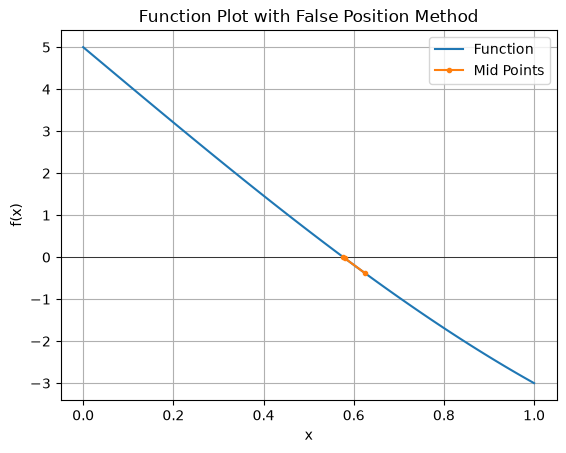

In [78]:
def FalsePosition( maxIterations: int , lowerLimit: float , upperLimit: float , precisionLimits: float, precisontFunction: float , function: callable, verbose: bool = False, plotting: bool = False ) -> float:
    if plotting:
        midPoints = []
        x = np.linspace(lowerLimit, upperLimit, 100)
        y = function(x)
        plt.plot(x, y, label='Function')
        plt.axhline(0, color='black', lw=0.5)
        plt.title('Function Plot with False Position Method')
        plt.xlabel('x')
        plt.ylabel('f(x)')

    
    iteration: int = 0
    midPoint: float = 0.0
    previusMidPoint: float = 0.0
    functionAplicationLowerLimit: float = 0.0
    functionAplicationUpperLimit: float = 0.0
    functionAplicationMidPoint: float = 0.0
    relativeError: float = 0.0
    ans: float = 0.0


    if verbose:
        print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}, Function at Upper Limit: {functionAplicationUpperLimit:.5e}\n\tRelative Error: {relativeError:.5e}")
    
    while iteration < maxIterations:
        if abs( upperLimit - lowerLimit ) < precisionLimits:
            break

        functionAplicationLowerLimit = function(lowerLimit)
        functionAplicationUpperLimit = function(upperLimit)
        previusMidPoint = midPoint
        midPoint = ((lowerLimit * functionAplicationUpperLimit) - (upperLimit * functionAplicationLowerLimit)) / (functionAplicationUpperLimit - functionAplicationLowerLimit)
        functionAplicationMidPoint = function(midPoint)

        if iteration > 0:  
            relativeError = abs((midPoint - previusMidPoint) / midPoint)

        if abs(functionAplicationMidPoint) < precisontFunction:
            ans = midPoint
            break
              
        if abs(functionAplicationLowerLimit) < precisontFunction:
            if plotting:    
                midPoints.append(lowerLimit)
            ans = lowerLimit
            break
            
        if abs(functionAplicationUpperLimit) < precisontFunction:
            if plotting:    
                midPoints.append(upperLimit)
            ans = upperLimit
            break

        if plotting:
            midPoints.append(midPoint)

        if functionAplicationLowerLimit * functionAplicationMidPoint > 0:
            lowerLimit = midPoint
        else:
            upperLimit = midPoint

        iteration += 1
        if verbose:
            print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}, Function at Upper Limit: {functionAplicationUpperLimit:.5e}\n\tRelative Error: {relativeError:.5e}")

    
    if iteration == maxIterations:
        print(f"Maximum iterations reached: {maxIterations}. The root may not have been found within the desired precision.")
        midPoint = (lowerLimit + upperLimit) / float(2)
        midPoints.append(midPoint)
        ans = midPoints
    else:
        iteration += 1
        if midPoint != 0:
            relativeError = abs((midPoint - previusMidPoint) / midPoint)
        if verbose:
            print(f"Iteration: {iteration}\n\tLower Limit: {lowerLimit:.5e}, Upper Limit: {upperLimit:.5e}, Mid Point: {midPoint:.5e}\n\tFunction at Lower Limit: {functionAplicationLowerLimit:.5e}, Function at Mid Point: {functionAplicationMidPoint:.5e}, Function at Upper Limit: {functionAplicationUpperLimit:.5e}\n\tRelative Error: {relativeError:.5e}")
    if verbose:
        print(f"Root found at: {ans:.5e} after {iteration} iterations with precision limit: {precisionLimits:.5e} and precision for function: {precisontFunction:.5e}")
    
    if plotting:    
        midPointsFx = [function(mid) for mid in midPoints]
        plt.plot(midPoints, midPointsFx, marker='.', label='Mid Points')
        plt.legend()
        plt.grid()
        plt.show()
    return ans



## Test Function

## [0,1] precision 5e-4
functionFalsePosition: callable = lambda x: x**3 - (9 * x) + 5

rootFalsePosition: float = FalsePosition(100, 0, 1, 5e-4 , 5e-4 , functionFalsePosition, verbose=True, plotting=True)

## Newton-Raphson

**Characteristics:** Uses the function and its derivative to extrapolate a tangent line to the next estimate; converges quadratically near the root. Only needs a single initial guess, not a bracket.

**Limitations:** Requires the derivative `f'(x)` to be known/computable. Can diverge, cycle, or converge to the wrong root with a poor initial guess or near-zero derivative. No sign-change safeguard.

**Best use:** Smooth functions with an easy-to-compute derivative and a good initial guess close to the root.

**Worst use:** Unknown/expensive derivatives, near-zero derivative regions, inflection points, or multiple close roots.


Iteration: 0, Current Estimate: 7.50000e-01
Iteration: 1
	Current Estimate: 7.50000e-01, Next Estimate: 5.68376e-01
	Function at Current Estimate: -1.32812e+00, Function Prime at Current Estimate: -7.31250e+00
	Relative Error: 0.00000e+00
Iteration: 2
	Current Estimate: 5.68376e-01, Next Estimate: 5.76872e-01
	Function at Current Estimate: 6.82300e-02, Function Prime at Current Estimate: -8.03085e+00
	Relative Error: 1.47277e-02
Iteration: 3
	Current Estimate: 5.68376e-01, Next Estimate: 5.76872e-01
	Function at Current Estimate: 6.82300e-02, Function Prime at Current Estimate: -8.03085e+00
	Relative Error: 1.47277e-02
Root found at: 5.76872e-01 after 3 iterations with precision difference: 1.00000e-02 and precision point: 1.00000e-02


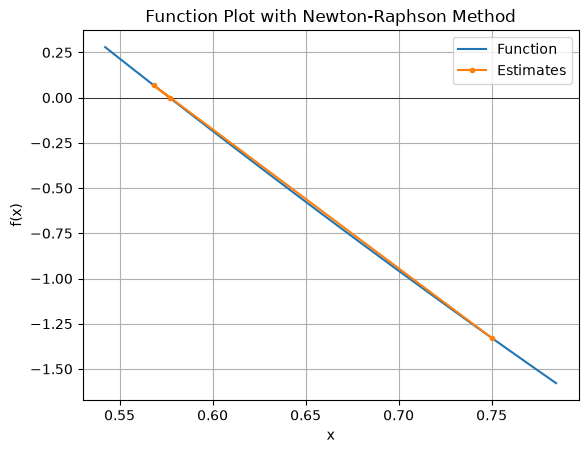

In [79]:
def NewtonRaphson( maxIterations: int , initialEstimate: float , precisionDifference: float , precisionPoint: float , function: callable , functionPrime: callable, verbose: bool = False, plotting: bool = False ) -> float:

    if plotting:
        estimates = []
        initialPoint = initialEstimate
        plt.axhline(0, color='black', lw=0.5)
        plt.title('Function Plot with Newton-Raphson Method')
        plt.xlabel('x')
        plt.ylabel('f(x)')

    iteration: int = 0
    previousEstimate: float = initialEstimate
    estimate: float = 0.0
    relativeError: float = 0.0
    ans: float = 0.0     
        
    if verbose:
        print(f"Iteration: {iteration}, Current Estimate: {previousEstimate:.5e}")

    while iteration < maxIterations:
        if abs(function(previousEstimate)) < precisionPoint:
            if plotting:
                estimates.append(previousEstimate)
            ans = previousEstimate
            break
        
        estimate = previousEstimate - (function(previousEstimate) / functionPrime(previousEstimate))    
        if iteration > 0:
            relativeError = abs((estimate - previousEstimate) / estimate)

        iteration += 1
        if plotting:
            estimates.append(previousEstimate)

        if verbose:
            print(f"Iteration: {iteration}\n\tCurrent Estimate: {previousEstimate:.5e}, Next Estimate: {estimate:.5e}\n\tFunction at Current Estimate: {function(previousEstimate):.5e}, Function Prime at Current Estimate: {functionPrime(previousEstimate):.5e}\n\tRelative Error: {relativeError:.5e}")

        if abs(estimate - previousEstimate) < precisionDifference or abs(function(estimate)) < precisionPoint:
            if plotting:
                estimates.append(estimate)
            ans = estimate 
            break

        previousEstimate = estimate


    if iteration == maxIterations:
        print(f"Maximum iterations reached: {maxIterations}. The root may not have been found within the desired precision.")
    else:
        iteration += 1
        if estimate != 0:
            relativeError = abs((estimate - previousEstimate) / estimate)
        if verbose:
            print(f"Iteration: {iteration}\n\tCurrent Estimate: {previousEstimate:.5e}, Next Estimate: {estimate:.5e}\n\tFunction at Current Estimate: {function(previousEstimate):.5e}, Function Prime at Current Estimate: {functionPrime(previousEstimate):.5e}\n\tRelative Error: {relativeError:.5e}")
    if verbose:
        print(f"Root found at: {ans:.5e} after {iteration} iterations with precision difference: {precisionDifference:.5e} and precision point: {precisionPoint:.5e}")

    if plotting:
        delta = abs(0.2 *(initialPoint - estimate))
        if estimate > initialPoint:
            x = np.linspace( initialPoint - delta , estimate + delta , 100)
        else:
            x = np.linspace( estimate - delta , initialPoint + delta , 100)
        y = function(x)
        plt.plot(x, y, label='Function')
        estimatesFx = [function(mid) for mid in estimates]
        plt.plot(estimates, estimatesFx, marker='.', label='Estimates')
        plt.legend()
        plt.grid()
        plt.show()

    return ans
## Test Function

## initial estimate 0.75 precision 1e-2
functionNewton: callable = lambda x: x**3 - (9 * x) + 5
functionNewtonPrime: callable = lambda x: 3 * (x**2) - 9

    
root1: float = NewtonRaphson(100, 0.75, 1e-2, 1e-2, functionNewton, functionNewtonPrime, verbose=True, plotting=True)

## Secant

**Characteristics:** Like Newton-Raphson but replaces the derivative with a finite-difference approximation from the last two estimates — no analytic derivative needed. Superlinear convergence (order ≈ 1.618).

**Limitations:** Needs two initial estimates (not necessarily bracketing). Can diverge if estimates are far from the root or the function is near-flat between them. No bracket safeguard.

**Best use:** Smooth functions where the derivative is unavailable/costly, with reasonable initial estimates.

**Worst use:** Poorly-behaved/noisy functions, or widely-spaced/poor initial guesses.

Iteration: 0
	Initial Estimate One: 0.00000e+00, Function at: 3.00000e+00
	Initial Estimate Two: 1.00000e+00, Function at: -5.00000e+00
	Estimate: 0.00000e+00, Function at Estimate: NILL
	, Relative Error: 0.00000e+00
Iteration: 1
	Initial Estimate One: 0.00000e+00, Function at: 3.00000e+00
	Initial Estimate Two: 1.00000e+00, Function at: -5.00000e+00
	Estimate: 3.75000e-01, Function at Estimate: -3.22266e-01
	Relative Error: 1.66667e+00
Iteration: 2
	Initial Estimate One: 1.00000e+00, Function at: -5.00000e+00
	Initial Estimate Two: 3.75000e-01, Function at: -3.22266e-01
	Estimate: 3.31942e-01, Function at Estimate: 4.91011e-02
	Relative Error: 1.29717e-01
Iteration: 3
	Initial Estimate One: 3.75000e-01, Function at: -3.22266e-01
	Initial Estimate Two: 3.31942e-01, Function at: 4.91011e-02
	Estimate: 3.37635e-01, Function at Estimate: -2.22206e-04
	Relative Error: 1.68616e-02
Root found at: 3.37635e-01 after 3 iterations with precision difference: 5.00000e-04 and precision point: 5.00

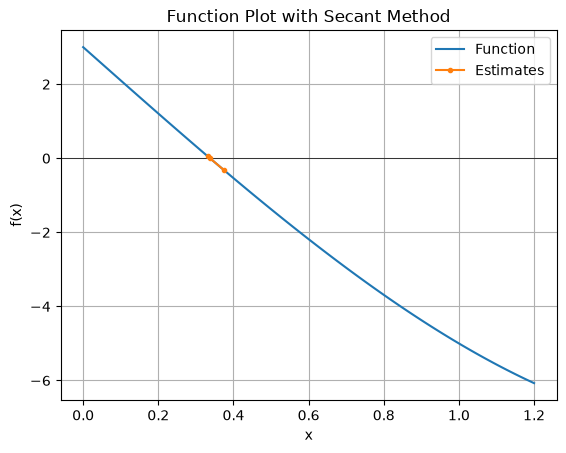

In [80]:
def Secant( maxIterations: int , initialEstimateOne: float , initialEstimateTwo: float , precisionDifference: float , precisionPoint: float , function: callable , verbose: bool = False , plotting: bool = False ) -> float:

    if plotting:
        estimates = []
        initialPointOne = initialEstimateOne
        initialPointTwo = initialEstimateTwo
        plt.axhline(0, color='black', lw=0.5)
        plt.title('Function Plot with Secant Method')
        plt.xlabel('x')
        plt.ylabel('f(x)')

    iteration: int = 0
    previousEstimateOne: float = initialEstimateOne
    previousEstimateTwo: float = initialEstimateTwo
    estimateOne: float = function(previousEstimateOne)
    estimateTwo: float = function(previousEstimateTwo)
    estimate: float = 0.0
    relativeError: float = 0.0
    ans: float = 0

    if verbose:
        print(f"Iteration: {iteration}\n\tInitial Estimate One: {previousEstimateOne:.5e}, Function at: {estimateOne:.5e}\n\tInitial Estimate Two: {previousEstimateTwo:.5e}, Function at: {estimateTwo:.5e}\n\tEstimate: {estimate:.5e}, Function at Estimate: NILL\n\t, Relative Error: {relativeError:.5e}")


    while iteration < maxIterations:
        if abs(estimateOne) < precisionPoint or abs(previousEstimateTwo - previousEstimateOne) < precisionDifference:
            ans = previousEstimateOne
            if plotting:
                estimates.append(previousEstimateOne)
            break

        estimate = previousEstimateTwo - ( estimateTwo * (previousEstimateTwo - previousEstimateOne) ) / (estimateTwo - estimateOne)
        if plotting:
            estimates.append(estimate)


        if abs(estimate - previousEstimateTwo) < precisionDifference or abs(function(estimate)) < precisionPoint:
            ans = estimate
            break

        relativeError = abs((estimate - previousEstimateTwo) / estimate)

        iteration += 1
        if verbose:
            print(f"Iteration: {iteration}\n\tInitial Estimate One: {previousEstimateOne:.5e}, Function at: {estimateOne:.5e}\n\tInitial Estimate Two: {previousEstimateTwo:.5e}, Function at: {estimateTwo:.5e}\n\tEstimate: {estimate:.5e}, Function at Estimate: {function(estimate):.5e}\n\tRelative Error: {relativeError:.5e}")

        previousEstimateOne = previousEstimateTwo
        previousEstimateTwo = estimate
        estimateOne = estimateTwo
        estimateTwo = function(estimate)
        
    if iteration == maxIterations:
        print(f"Maximum iterations reached: {maxIterations}. The root may not have been found within the desired precision.")
        ans = estimate
    else:
        iteration += 1
        relativeError = abs((estimate - previousEstimateTwo) / estimate)
        if verbose:
            print(f"Iteration: {iteration}\n\tInitial Estimate One: {previousEstimateOne:.5e}, Function at: {estimateOne:.5e}\n\tInitial Estimate Two: {previousEstimateTwo:.5e}, Function at: {estimateTwo:.5e}\n\tEstimate: {estimate:.5e}, Function at Estimate: {function(estimate):.5e}\n\tRelative Error: {relativeError:.5e}")
    if verbose:
        print(f"Root found at: {ans:.5e} after {iteration} iterations with precision difference: {precisionDifference:.5e} and precision point: {precisionPoint:.5e}")

    if plotting:
        if initialPointOne > initialPointTwo:
            x = np.linspace( initialPointTwo * 0.8 , initialPointOne * 1.2 , 100)
        else:
            x = np.linspace( initialPointOne * 0.8 , initialPointTwo * 1.2 , 100)
        y = function(x)
        plt.plot(x, y, label='Function')
        estimatesFx = [function(mid) for mid in estimates]
        plt.plot(estimates, estimatesFx, marker='.', label='Estimates')
        plt.legend()
        plt.grid()
        plt.show()


    return ans

## Test Function

## initial estimate 0.75 precision 1e-2
functionSecant: callable = lambda x: x**3 - (9 * x) + 3

    
root1: float = Secant(100, 0 , 1, 5e-4, 5e-4, functionSecant, verbose=True, plotting=True)

# Assigment 1

### 1. Queda de um paraquedista (Método da Bissecção)

Considere um paraquedista de massa $m$ em queda vertical. Admitindo que a resistência do ar seja proporcional à velocidade, sua velocidade em função do tempo pode ser modelada por

$$
v(t) = \frac{gm}{c}\left(1 - e^{-ct/m}\right),
$$

em que: $m$ é a massa do paraquedista, em kg; $g$ é a aceleração da gravidade, em m/s²; $c$ é o coeficiente de resistência do ar, em kg/s; $t$ é o tempo, em s.

Durante um ensaio foram obtidos os seguintes dados $m = 68{,}1$ kg, $g = 9{,}81$ m/s², e verificou-se que, após $t = 10$ s, o paraquedista apresentava velocidade $v = 40$ m/s. Deseja-se determinar experimentalmente o coeficiente $c$.

---

**a)** Transforme o modelo em uma equação da forma $f(c) = 0$.
#### **Answer**:

$$
v(t) = \frac{gm}{c}\left(1 - e^{-ct/m}\right)
$$

$$
40 = \frac{9,81 * 68,1}{c}\left(1 - e^{-c * 10/68,1}\right)
$$

$$
40 = \frac{668.061}{c}\left(1 - e^{-c * 10/68,1}\right)
$$

$$
0 = \frac{668.061}{c}\left(1 - e^{-c * 10/68,1}\right) - 40
$$

$$
f(c) = \frac{668.061}{c}\left(1 - e^{-c * 10/68,1}\right) - 40
$$

$$
(Generalized)
$$
$$
f(c,g,m,t,v) = \frac{gm}{c}\left(1 - e^{-ct/m}\right) - v            
$$

In [81]:
function1generalized: callable = lambda c, g, m, t, v: (g * m / c) * ( 1 - np.exp( (-c * t) / m ) ) - v
function1applied: callable = lambda c: function1generalized(c, 9.81, 68.1, 10, 40)

**b)** Construa o gráfico de $f(c)$ para $5 \leq c \leq 25$ kg/s e identifique a região da raiz.
#### **Answer**

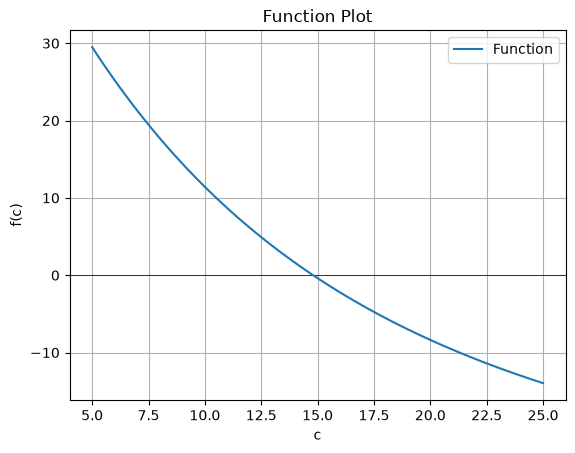

In [82]:
plt.axhline(0, color='black', lw=0.5)
plt.title('Function Plot')
plt.xlabel('c')
plt.ylabel('f(c)')
x = np.linspace( 5 , 25 , 100)
y = function1applied(x)
plt.plot(x, y, label='Function')
plt.legend()
plt.grid()
plt.show()

**c)** Verifique numericamente que existe pelo menos uma raiz no intervalo $[10, 20]$. Explique matematicamente por que a mudança de sinal é importante no Método da Bissecção.
#### **Answer**

In [83]:
print( f"f(10) = {function1applied(10)}" )
print( f"f(20) = {function1applied(20)}" )

f(10) = 11.42152148536995
f(20) = -8.368384465361824


There is a sign change between the values of f(c) at the two endpoints of the interval. By the Intermediate Value Theorem, since f is continuous on [10, 20] (as confirmed by the plot), a sign change guarantees that at least one root lies between those two points.

This sign change is essential to the Bisection Method because the method relies entirely on it to know whether the root lies in the current interval: at each iteration, it checks the sign of f at the midpoint and keeps the sub-interval where the sign change occurs, discarding the other. If f(a) and f(b) do not have opposite signs, the method has no way to guarantee a root exists inside [a, b], and it may converge to the wrong region, or fail to converge to a root at all.

**d)** Determine $c$ utilizando o Método da Bissecção. Apresente uma tabela contendo $i, c_l, c_u, c_r, f(c_r), \varepsilon_a$.

#### **Answer**

|  i |        $c_l$ |        $c_u$ |        $c_r$ |     $f(c_r)$ |      $\varepsilon_a$ |
| -: | -----------: | -----------: | -----------: | -----------: | --------------------: |
|  0 | 1.00000e+01 | 2.00000e+01 | 0.00000e+00 |  0.00000e+00 |            — |
|  1 | 1.00000e+01 | 1.50000e+01 | 1.50000e+01 | -3.84458e-01 |            — |
|  2 | 1.25000e+01 | 1.50000e+01 | 1.25000e+01 |  4.91893e+00 | 2.00000e-01 |
|  3 | 1.37500e+01 | 1.50000e+01 | 1.37500e+01 |  2.13515e+00 | 9.09091e-02 |
|  4 | 1.43750e+01 | 1.50000e+01 | 1.43750e+01 |  8.44298e-01 | 4.34783e-02 |
|  5 | 1.46875e+01 | 1.50000e+01 | 1.46875e+01 |  2.22390e-01 | 2.12766e-02 |
|  6 | 1.46875e+01 | 1.48438e+01 | 1.48438e+01 | -8.28884e-02 | 1.05263e-02 |
|  7 | 1.47656e+01 | 1.48438e+01 | 1.47656e+01 |  6.92837e-02 | 5.29101e-03 |
|  8 | 1.47656e+01 | 1.48047e+01 | 1.48047e+01 | -6.91868e-03 | 2.63852e-03 |
|  9 | 1.47852e+01 | 1.48047e+01 | 1.47852e+01 |  3.11534e-02 | 1.32100e-03 |
| 10 | 1.47949e+01 | 1.48047e+01 | 1.47949e+01 |  1.21101e-02 | 6.60066e-04 |
| 11 | 1.47998e+01 | 1.48047e+01 | 1.47998e+01 |  2.59388e-03 | 3.29924e-04 |
| 12 | 1.47998e+01 | 1.48022e+01 | 1.48022e+01 | -2.16285e-03 | 1.64935e-04 |
| 13 | 1.48010e+01 | 1.48022e+01 | 1.48010e+01 |  2.15399e-04 | 8.24742e-05 |
| 14 | 1.48010e+01 | 1.48016e+01 | 1.48016e+01 | -9.73756e-04 | 4.12354e-05 |
| 15 | 1.48010e+01 | 1.48013e+01 | 1.48013e+01 | -3.79186e-04 | 2.06181e-05 |
| 16 | 1.48010e+01 | 1.48013e+01 | 1.48012e+01 | -8.18955e-05 | 1.03092e-05 |

$$
\boxed{c \approx 1.48012 \times 10^1 \text{ kg/s}}
$$
$$
\boxed{\text{precisão} = 1 \times 10^{-4}}
$$

Iteration: 0
	Lower Limit: 1.00000e+01, Upper Limit: 2.00000e+01, Mid Point: 0.00000e+00
	Function at Lower Limit: 0.00000e+00,Function at Upper Limit: 0.00000e+00, Function at Mid Point: 0.00000e+00
	Relative Error: 0.00000e+00
Iteration: 1
	Lower Limit: 1.00000e+01, Upper Limit: 1.50000e+01, Mid Point: 1.50000e+01
	Function at Lower Limit: 1.14215e+01,Function at Upper Limit: -8.36838e+00, Function at Mid Point: -3.84458e-01
	Relative Error: 0.00000e+00
Iteration: 2
	Lower Limit: 1.25000e+01, Upper Limit: 1.50000e+01, Mid Point: 1.25000e+01
	Function at Lower Limit: 1.14215e+01,Function at Upper Limit: -3.84458e-01, Function at Mid Point: 4.91893e+00
	Relative Error: 2.00000e-01
Iteration: 3
	Lower Limit: 1.37500e+01, Upper Limit: 1.50000e+01, Mid Point: 1.37500e+01
	Function at Lower Limit: 4.91893e+00,Function at Upper Limit: -3.84458e-01, Function at Mid Point: 2.13515e+00
	Relative Error: 9.09091e-02
Iteration: 4
	Lower Limit: 1.43750e+01, Upper Limit: 1.50000e+01, Mid Point: 1.4

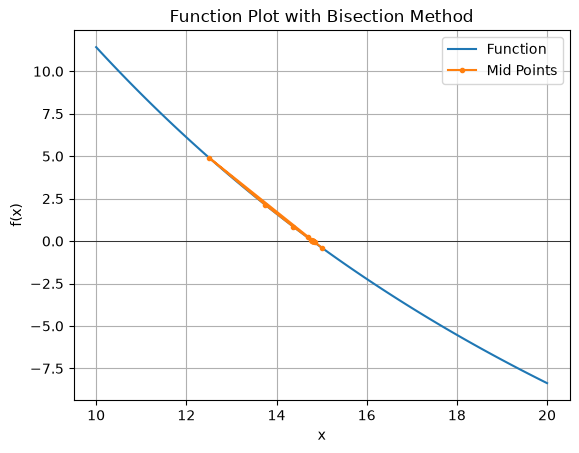

14.801177978515625

In [84]:
Bisection(100, 10, 20, 1e-4, function1applied, verbose=True, plotting=True)

**e)** Interprete fisicamente o resultado: o que representa um aumento no valor de $c$ para o movimento do paraquedista?
#### **Answer**

The value of \(c\) represents the **air resistance coefficient** acting on the parachutist. Therefore, an increase in \(c\) means greater air resistance opposing the parachutist's fall.

As \(c\) increases, the parachutist's acceleration decreases more rapidly, causing the velocity to increase more slowly. Consequently, the parachutist reaches a **lower terminal velocity**. This can be observed in the graphs: for larger values of \(c\), the velocity is lower at the same instant \(t\).

Conversely, when \(c\) is smaller, the air resistance is weaker, allowing the parachutist to accelerate for longer and reach a **higher terminal velocity**.

Thus, **an increase in \(c\) results in greater air resistance, lower acceleration, and lower velocity over time, including a lower terminal velocity.**

In [85]:
function1velocity: callable = lambda c, g, m, t: (g * m / c) * ( 1 - np.exp( (-c * t) / m ) ) 
print(f"Speed with c = 10 = {function1velocity(10, 9.81, 68.1, 10)}" )
print(f"Speed with c = 14.80 = {function1velocity(14.8011, 9.81, 68.1, 10)}" )
print(f"Speed with c = 20 = {function1velocity(20, 9.81, 68.1, 10)}" )

Speed with c = 10 = 51.42152148536995
Speed with c = 14.80 = 40.000070033189175
Speed with c = 20 = 31.631615534638176


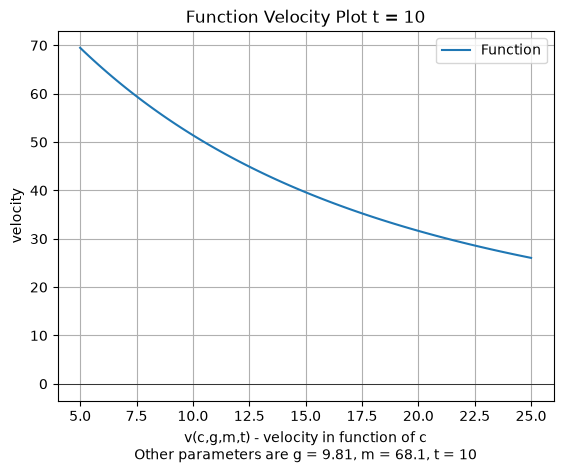

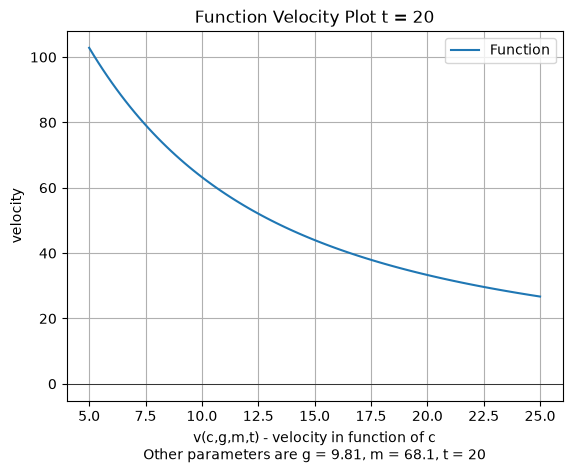

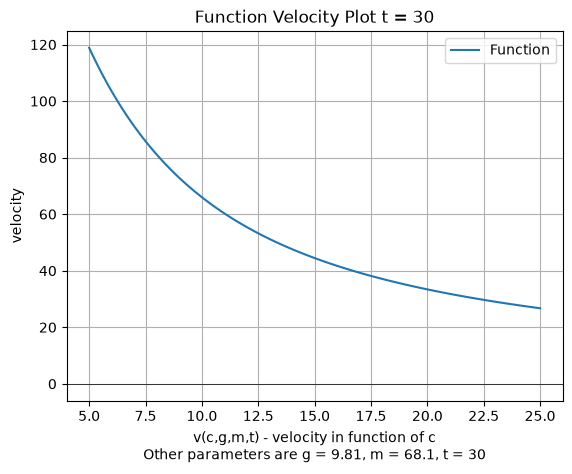

In [86]:
plt.axhline(0, color='black', lw=0.5)
plt.title('Function Velocity Plot t = 10')
plt.ylabel('velocity')
plt.xlabel('v(c,g,m,t) - velocity in function of c\nOther parameters are g = 9.81, m = 68.1, t = 10')
x = np.linspace( 5 , 25 , 100)
y = function1velocity(x, 9.81, 68.1, 10)
plt.plot(x, y, label='Function')
plt.legend()
plt.grid()
plt.show()

plt.axhline(0, color='black', lw=0.5)
plt.title('Function Velocity Plot t = 20')
plt.ylabel('velocity')
plt.xlabel('v(c,g,m,t) - velocity in function of c\nOther parameters are g = 9.81, m = 68.1, t = 20')
x = np.linspace( 5 , 25 , 100)
y = function1velocity(x, 9.81, 68.1, 20)
plt.plot(x, y, label='Function')
plt.legend()
plt.grid()
plt.show()

plt.axhline(0, color='black', lw=0.5)
plt.title('Function Velocity Plot t = 30')
plt.ylabel('velocity')
plt.xlabel('v(c,g,m,t) - velocity in function of c\nOther parameters are g = 9.81, m = 68.1, t = 30')
x = np.linspace( 5 , 25 , 100)
y = function1velocity(x, 9.81, 68.1, 30)
plt.plot(x, y, label='Function')
plt.legend()
plt.grid()
plt.show()

### 2. Canal retangular (Método da Falsa Posição)

Um canal retangular transporta água em regime permanente. A vazão pode ser estimada pela equação de Manning,

$$
Q = \frac{1}{n} A R_h^{2/3} S^{1/2},
$$

em que $A$ é a área molhada, $R_h$ é o raio hidráulico, $S$ é a declividade do canal e $n$ é o coeficiente de rugosidade.

Para um canal retangular de largura $b$ e profundidade da água $y$,

$$
A = by
$$

e

$$
R_h = \frac{by}{b+2y}.
$$

Considere: $b = 3,0$ m, $n = 0,025$, $S = 0,001$ e uma vazão desejada $Q = 5,0$ m³/s. Deseja-se determinar a profundidade $y$ necessária para transportar essa vazão.


**a)** Transforme o modelo em uma equação da forma $f(y) = 0$.
#### **Answer**

$$
(Generalized)
$$

$$
f(y,b,n,Q,S) = \frac{1}{n}by(\frac{by}{b+2y})^{2/3} S^{1/2} - Q
$$

$$
(Applied)
$$

$$
f(y) = \frac{1}{0,025}3y(\frac{3y}{3+2y})^{2/3} 0,001^{1/2} - 5
$$

**b)** Construa o gráfico de $f(y)$ para $0,2 \leq y \leq 3,0$ m e estime a profundidade da água.
#### **Answer**
Root between $1,25$ and $1,75$, verified by sign change

In [87]:
function2Generalized: callable = lambda y , n , b , s , q: ((1 / n) * b * y * (( ( b * y ) / ( b + ( 2 * y )) ) ** ( 2 / 3 )) * s ** (( 1 / 2))) - q
function2Applied: callable = lambda y: function2Generalized(y, 0.025 , 3 , 0.001 , 5)

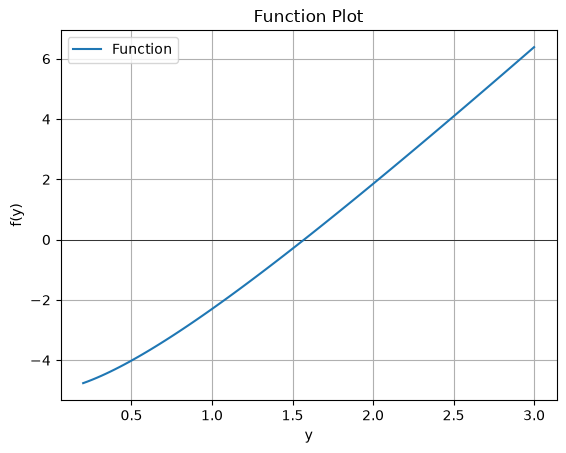

In [88]:
plt.axhline(0, color='black', lw=0.5)
plt.title('Function Plot')
plt.xlabel('y')
plt.ylabel('f(y)')
x = np.linspace( 0.2 , 3 , 100)
y = function2Applied(x)
plt.plot(x, y, label='Function')
plt.legend()
plt.grid()
plt.show()

In [89]:
print(f"Value at 1,25 = {function2Applied(1.25)}")
print(f"Value at 1,75 = {function2Applied(1.75)}")

Value at 1,25 = -1.3254543718052774
Value at 1,75 = 0.759479797494512


**c)** Utilize o Método da Falsa Posição para determinar $y$. Apresente uma tabela contendo $i$, $y_l$, $y_u$, $y_r$, $f(y_r)$, $\varepsilon_a$.

#### **Answer**

| $i$ | $y_l$ | $y_u$ | $y_r$ | $f(y_r)$ | $\varepsilon_a$ |
|---:|---:|---:|---:|---:|---:|
| 0 | $1.25000\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $0.00000\mathrm{e}{+00}$ | $0.00000\mathrm{e}{+00}$ | $0.00000\mathrm{e}{+00}$ |
| 1 | $1.56786\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $1.56786\mathrm{e}{+00}$ | $-1.65249\mathrm{e}{-02}$ | $0.00000\mathrm{e}{+00}$ |
| 2 | $1.57174\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $1.57174\mathrm{e}{+00}$ | $-1.74447\mathrm{e}{-04}$ | $2.46767\mathrm{e}{-03}$ |
| 3 | $1.57178\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $1.57178\mathrm{e}{+00}$ | $-1.83813\mathrm{e}{-06}$ | $2.60436\mathrm{e}{-05}$ |
| 4 | $1.57178\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $1.57178\mathrm{e}{+00}$ | $-1.93678\mathrm{e}{-08}$ | $2.74418\mathrm{e}{-07}$ |
| 5 | $1.57178\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $1.57178\mathrm{e}{+00}$ | $-2.04071\mathrm{e}{-10}$ | $2.89146\mathrm{e}{-09}$ |
| 6 | $1.57178\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $1.57178\mathrm{e}{+00}$ | $-2.15117\mathrm{e}{-12}$ | $3.04661\mathrm{e}{-11}$ |
| 7 | $1.57178\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $1.57178\mathrm{e}{+00}$ | $-2.22045\mathrm{e}{-14}$ | $3.21246\mathrm{e}{-13}$ |
| 8 | $1.57178\mathrm{e}{+00}$ | $1.75000\mathrm{e}{+00}$ | $1.57178\mathrm{e}{+00}$ | $0.00000\mathrm{e}{+00}$ | $3.39046\mathrm{e}{-15}$ |

Therefore,

$$
\boxed{y \approx 1.57178\mathrm{e}{+00}\ \text{m}}
$$

Iteration: 0
	Lower Limit: 1.25000e+00, Upper Limit: 1.75000e+00, Mid Point: 0.00000e+00
	Function at Lower Limit: 0.00000e+00, Function at Mid Point: 0.00000e+00, Function at Upper Limit: 0.00000e+00
	Relative Error: 0.00000e+00
Iteration: 1
	Lower Limit: 1.56786e+00, Upper Limit: 1.75000e+00, Mid Point: 1.56786e+00
	Function at Lower Limit: -1.32545e+00, Function at Mid Point: -1.65249e-02, Function at Upper Limit: 7.59480e-01
	Relative Error: 0.00000e+00
Iteration: 2
	Lower Limit: 1.57174e+00, Upper Limit: 1.75000e+00, Mid Point: 1.57174e+00
	Function at Lower Limit: -1.65249e-02, Function at Mid Point: -1.74447e-04, Function at Upper Limit: 7.59480e-01
	Relative Error: 2.46767e-03
Iteration: 3
	Lower Limit: 1.57178e+00, Upper Limit: 1.75000e+00, Mid Point: 1.57178e+00
	Function at Lower Limit: -1.74447e-04, Function at Mid Point: -1.83813e-06, Function at Upper Limit: 7.59480e-01
	Relative Error: 2.60436e-05
Iteration: 4
	Lower Limit: 1.57178e+00, Upper Limit: 1.75000e+00, Mid Poin

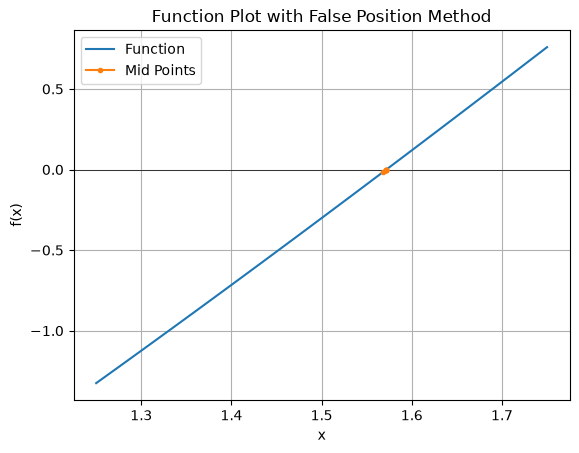

1.5717847161669152

In [90]:
FalsePosition(100, 1.25, 1.75, 1e-20 , 1e-20 , function2Applied, verbose=True, plotting=True)

**d)** Explique por que o Método da Falsa Posição produz aproximações diferentes do Método da Bissecção, embora ambos os métodos preservem um intervalo contendo a raiz.
#### **Answer**

Both methods keep an interval that always contains the root, but they choose the next approximation differently. Bisection always picks the **midpoint** of the interval, ignoring the actual shape (magnitude) of f(y) at the endpoints, it only uses the sign of f. The False Position Method instead draws a straight line (secant) connecting (y_l, f(y_l)) and (y_u, f(y_u)) and uses the point where that line crosses zero as the next estimate. This means False Position takes into account how close each endpoint's function value is to zero, weighting the estimate toward the endpoint with the smaller |f(y)|. As a result, when f(y) is not linear near the root, the False Position estimate is usually closer to the true root than the plain midpoint, so the two methods converge to the same root but through different sequences of approximations, often with False Position needing fewer iterations, though it can occasionally stall if one endpoint stays fixed over many iterations.



**e)** Apresente a profundidade final em metros e em centímetros e interprete o resultado do ponto de vista do
dimensionamento do canal.
#### **Answer**

The computed root is

$$
y \approx 1.5718 \text{ m} = 157.18 \text{ cm}
$$

This means the rectangular channel needs a water depth of about **1.57 m (≈157 cm)** to carry the desired flow rate of 5.0 m³/s under the given slope and roughness conditions. From a channel design standpoint, this tells the engineer the minimum wall height the channel must have to avoid overflow at this flow rate, the physical channel would need to be built with a depth of at least this value (plus a safety freeboard margin) to safely convey the design discharge.

**e)** Apresente a profundidade final em metros e em centímetros e interprete o resultado do ponto de vista do dimensionamento do canal.
#### **Answer**

### 3. Para pressões suficientemente elevadas, a hipótese de gás ideal pode tornar-se inadequada. Uma aproximação mais realista é fornecida pela equação de van der Waals,

$$
\left(P + \frac{a}{v^2}\right)(v - b) = RT,
$$

em que $v$ representa o volume molar.

Considere dióxido de carbono a $T = 300$ K e $P = 10$ bar, com $a = 3{,}592$ L² bar/mol², $b = 0{,}04267$ L/mol e $R = 0{,}08314$ L bar/(mol K). Deseja-se determinar o volume molar $v$ previsto pela equação de van der Waals.

**a)** Transforme o modelo em uma equação da forma $f(v) = 0$.
#### **Answer**
$$
(Generalized)
$$

$$
f(v,b,a,P,R,T) = \left(P + \frac{a}{v^2}\right)(v - b) - RT,
$$

$$
(Applied)
$$

$$
f(v) = \left(10 + \frac{3,592}{v^2}\right)(v - 0,04267) - 0,08314 * 300,
$$

**b)** Construa o gráfico de $f(v)$ para $0{,}5 \leq v \leq 4{,}0$ L/mol e identifique a raiz fisicamente relevante.
#### **Answer**
We can identify one relevant root, around 2,4.

In [91]:
function3Generalized: callable = lambda v , b , a , P , R , T: ( P + ( a / v ** 2 ) ) * ( v - b ) - ( R * T )
function3Applied: callable = lambda v: function3Generalized(v, 0.04267 , 3.592 , 10 , 0.08314 , 300)

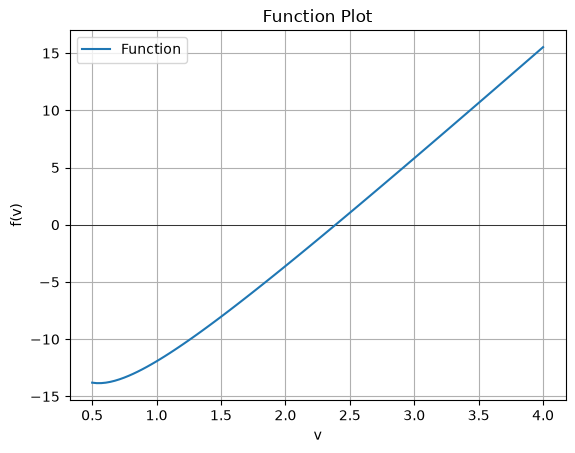

In [92]:
plt.axhline(0, color='black', lw=0.5)
plt.title('Function Plot')
plt.xlabel('v')
plt.ylabel('f(v)')
x = np.linspace( 0.5 , 4 , 100)
y = function3Applied(x)
plt.plot(x, y, label='Function')
plt.legend()
plt.grid()
plt.show()

**c)** A lei dos gases ideais fornece $v_{ideal} = \dfrac{RT}{P}$. Calcule esse valor e utilize-o como aproximação inicial $v_0 = v_{ideal}$. Explique por que essa escolha é fisicamente razoável.
#### **Answer**
It's a reasonable approximation because it gives a volume value using a simpler model. It is not going to be precise, but it is good enough for an approximation. As can be seen, the calculated $v_{ideal}$ is close to the root in the graph.

In [93]:
vIdeal = 0.08314 * 300 / 10
print(vIdeal)

2.4942


**d)** Utilize o Método de Newton-Raphson para determinar $v$. Apresente uma tabela contendo $i$, $v_i$, $f(v_i)$, $f'(v_i)$, $v_{i+1}$, $\varepsilon_a$.

#### **Answer**

| $i$ | $v_i$ | $f(v_i)$ | $f'(v_i)$ | $v_{i+1}$ | $\varepsilon_a$ (%) |
|---:|---:|---:|---:|---:|---:|
| 0 | $2.49420\mathrm{e}{+00}$ | — | — | $2.49420\mathrm{e}{+00}$ | $0.00000\mathrm{e}{+00}$ |
| 1 | $2.49420\mathrm{e}{+00}$ | $9.88804\mathrm{e}{-01}$ | $9.44236\mathrm{e}{+00}$ | $2.38948\mathrm{e}{+00}$ | $0.00000\mathrm{e}{+00}$ |
| 2 | $2.38948\mathrm{e}{+00}$ | $2.51191\mathrm{e}{-03}$ | $9.39335\mathrm{e}{+00}$ | $2.38921\mathrm{e}{+00}$ | $1.11925\mathrm{e}{-04}$ |
| 3 | $2.38921\mathrm{e}{+00}$ | $1.78209\mathrm{e}{-08}$ | $9.39322\mathrm{e}{+00}$ | $2.38921\mathrm{e}{+00}$ | $7.94071\mathrm{e}{-10}$ |
| 4 | $2.38921\mathrm{e}{+00}$ | $1.78209\mathrm{e}{-08}$ | $9.39322\mathrm{e}{+00}$ | $2.38921\mathrm{e}{+00}$ | $7.94071\mathrm{e}{-10}$ |

Therefore,

$$
\boxed{v \approx 2.38921\mathrm{e}{+00}\ \text{L/mol}}
$$

In [94]:
v = symbols('v')
f = (( 10 + ( 3.592 / (v ** 2) ) ) * ( v - 0.04267 )) - ( 0.08314 * 300 )
f_prime = diff(f, v)

print(f_prime)

function3Prime: callable = lambda v: ( 10 + ( 3.592 / (v ** 2) ) ) - ( ( 7.184 * ( v - 0.04267 ) ) / ( v ** 3 ) )


10 + 3.592/v**2 - 7.184*(v - 0.04267)/v**3


Iteration: 0, Current Estimate: 2.49420e+00
Iteration: 1
	Current Estimate: 2.49420e+00, Next Estimate: 2.38948e+00
	Function at Current Estimate: 9.88804e-01, Function Prime at Current Estimate: 9.44236e+00
	Relative Error: 0.00000e+00
Iteration: 2
	Current Estimate: 2.38948e+00, Next Estimate: 2.38921e+00
	Function at Current Estimate: 2.51191e-03, Function Prime at Current Estimate: 9.39335e+00
	Relative Error: 1.11925e-04
Iteration: 3
	Current Estimate: 2.38921e+00, Next Estimate: 2.38921e+00
	Function at Current Estimate: 1.78209e-08, Function Prime at Current Estimate: 9.39322e+00
	Relative Error: 7.94071e-10
Iteration: 4
	Current Estimate: 2.38921e+00, Next Estimate: 2.38921e+00
	Function at Current Estimate: 1.78209e-08, Function Prime at Current Estimate: 9.39322e+00
	Relative Error: 7.94071e-10
Root found at: 2.38921e+00 after 4 iterations with precision difference: 1.00000e-20 and precision point: 1.00000e-20


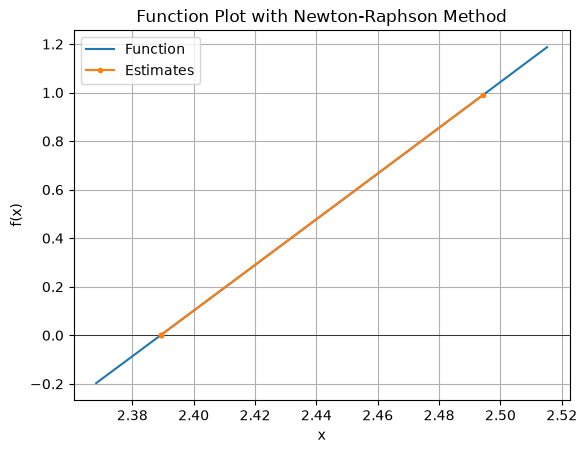

2.3892126140582164

In [95]:
NewtonRaphson(100, vIdeal, 1e-20, 1e-20, function3Applied, function3Prime, verbose=True, plotting=True)

**e)** Compare o volume obtido pela equação de van der Waals com $v_{ideal}$. Calcule a diferença percentual

$$
\Delta v = \frac{|v-v_{ideal}|}{v_{ideal}} \times 100\%.
$$

Discuta o significado dessa diferença.
#### **Answer**
The diference comes from the structure of the equations, one is more complex and takes in to acount more varibles that contribute to the gas volume, when the other is a rought aproximation.


In [96]:
delta = abs(2.3892126140582164 - vIdeal) / vIdeal * 100
print(f"Delta = {delta:.2f}%")

Delta = 4.21%


### 4. Considere o circuito formado por uma fonte contínua $V_s$, um resistor $R$ e um diodo semicondutor conectados em série.

Para o diodo, utilize a equação de Shockley,

$$
I_D = I_S\left[\exp\left(\frac{V_D}{nV_T}\right) - 1\right],
$$

enquanto a corrente determinada pela fonte e pelo resistor é

$$
I_R = \frac{V_s - V_D}{R}.
$$

No ponto de operação do circuito, $I_D = I_R$.

Considere: $V_s = 5{,}0$ V, $R = 1000\ \Omega$, $I_S = 1{,}0 \times 10^{-12}$ A, $n = 1{,}7$, $V_T = 25{,}85 \times 10^{-3}$ V. Deseja-se determinar a tensão $V_D$ e a corrente do circuito.

**a)** Obtenha uma equação $f(V_D) = 0$ que determine o ponto de operação.
#### **Answer**

$$
(Generalized)
$$

$$
f(V_D,I_S,V_T,V_s,R,n) = I_S\left[\exp\left(\frac{V_D}{nV_T}\right) - 1\right] - \frac{V_s - V_D}{R}
$$

$$
(Applied)
$$

$$
f(V_D) = 1{,}0 \times 10^{-12}\left[\exp\left(\frac{V_D}{1,7 * 25{,}85 \times 10^{-3}}\right) - 1\right] - \frac{5 - V_D}{1000}
$$

**b)** Faça duas representações gráficas:
1. $I_D(V_D)$ e $I_R(V_D)$ no mesmo sistema de coordenadas;
2. $f(V_D)$ em função de $V_D$.
Utilize $0 \leq V_D \leq 1{,}1$ V. Explique o significado físico da interseção das duas curvas do gráfico.
#### **Answer**

1. **$I_D(V_D)$ and $I_R(V_D)$ (Image 1):** The diode curve stays essentially at zero for low $V_D$, then rises sharply (exponentially) as $V_D$ approaches ~1.0 V. The resistor line decreases almost linearly, since increasing $V_D$ reduces the voltage drop across the resistor and therefore the current $I_R = (V_s - V_D)/R$. The two curves **intersect** at around $V_D \approx 0.98$–$1.0$ V, where $I_D \approx I_R \approx 0.004$ A.

2. **$f(V_D)$ (Image 2):** This is simply $I_D(V_D) - I_R(V_D)$. It stays negative for most of the range (since $I_R > I_D$ there), crosses zero at the same point where the two curves in Image 1 intersect, and turns sharply positive right after, since the diode current overtakes the resistor current almost instantly once it starts conducting.

**Physical meaning of the intersection:** the crossing point is the circuit's **operating point (Q-point)**, the unique voltage $V_D$ and current at which the current flowing through the diode exactly equals the current supplied by the source through the resistor. Below this point, the resistor "wants" to push more current than the diode can carry at that voltage; above it, the diode would draw more current than the resistor circuit can supply. The intersection is therefore the stable, physically consistent condition the real circuit settles into, that is exactly the root of $f(V_D) = 0$ that the Secant method is being used to find.

In [97]:
function4DiodeApplied: callable = lambda Vd: 1e-12 * (np.exp( Vd / (1.7 * 25.85e-3) ) - 1 )
function4ResistorApplied: callable = lambda Vd: ( 5 - Vd ) / 1000
function4Applied: callable = lambda Vd: function4DiodeApplied(Vd) - function4ResistorApplied(Vd)

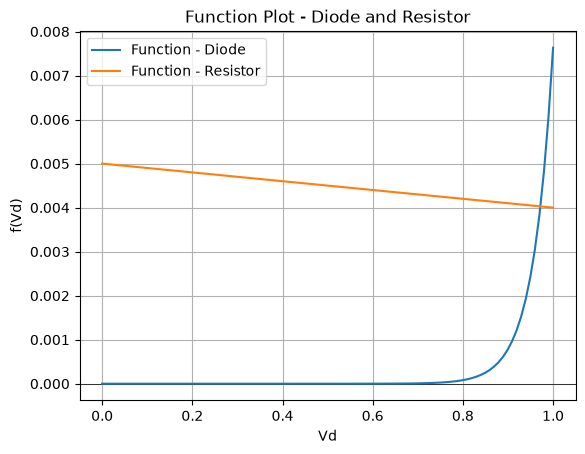

In [98]:
plt.axhline(0, color='black', lw=0.5)
plt.title('Function Plot - Diode and Resistor')
plt.xlabel('Vd')
plt.ylabel('f(Vd)')
x = np.linspace( 0 , 1 , 100)
y = function4DiodeApplied(x)
plt.plot(x, y, label='Function - Diode')
y = function4ResistorApplied(x)
plt.plot(x, y, label='Function - Resistor')
plt.legend()
plt.grid()
plt.show()

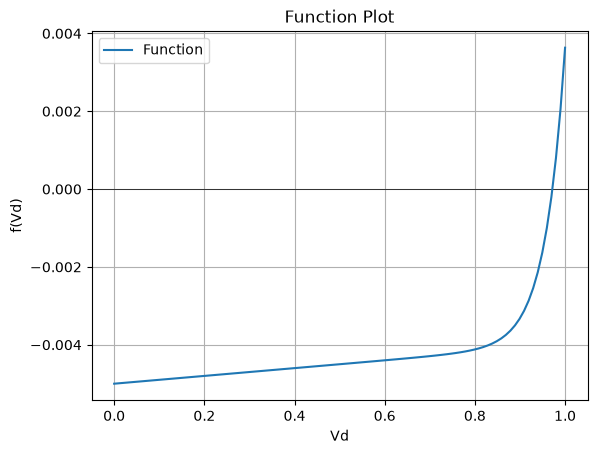

In [99]:
plt.axhline(0, color='black', lw=0.5)
plt.title('Function Plot')
plt.xlabel('Vd')
plt.ylabel('f(Vd)')
x = np.linspace( 0 , 1 , 100)
y = function4Applied(x)
plt.plot(x, y, label='Function')
plt.legend()
plt.grid()
plt.show()

**c)** Utilize $V_0 = 0{,}95$ V e $V_1 = 1{,}00$ V como valores iniciais do Método da Secante.
#### **Answer**

Iteration: 0
	Initial Estimate One: 9.50000e-01, Function at: -1.60348e-03
	Initial Estimate Two: 1.00000e+00, Function at: 3.63278e-03
	Estimate: 0.00000e+00, Function at Estimate: NILL
	, Relative Error: 0.00000e+00
Iteration: 1
	Initial Estimate One: 9.50000e-01, Function at: -1.60348e-03
	Initial Estimate Two: 1.00000e+00, Function at: 3.63278e-03
	Estimate: 9.65311e-01, Function at Estimate: -5.68394e-04
	Relative Error: 3.59352e-02
Iteration: 2
	Initial Estimate One: 1.00000e+00, Function at: 3.63278e-03
	Initial Estimate Two: 9.65311e-01, Function at: -5.68394e-04
	Estimate: 9.70005e-01, Function at Estimate: -1.73022e-04
	Relative Error: 4.83830e-03
Iteration: 3
	Initial Estimate One: 9.65311e-01, Function at: -5.68394e-04
	Initial Estimate Two: 9.70005e-01, Function at: -1.73022e-04
	Estimate: 9.72058e-01, Function at Estimate: 1.35706e-05
	Relative Error: 2.11286e-03
Iteration: 4
	Initial Estimate One: 9.70005e-01, Function at: -1.73022e-04
	Initial Estimate Two: 9.72058e-01,

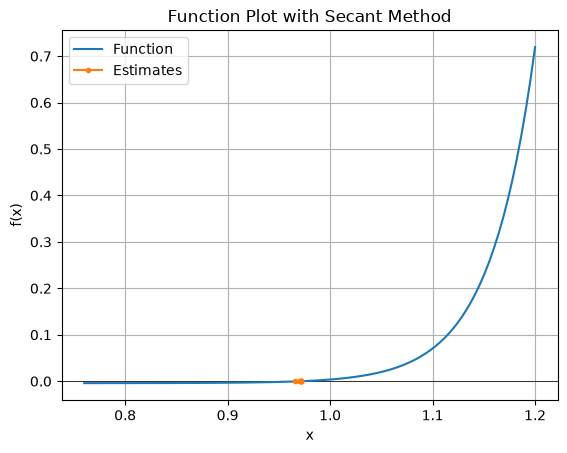

Root: 0.9719121249563771


In [100]:
print(f"Root: {Secant(100, 0.95 , 1, 5e-20, 5e-20, function4Applied, verbose=True, plotting=True)}")

**d)** Determine numericamente $V_D$. Apresente uma tabela contendo $i$, $V_{i-1}$, $V_i$, $f(V_{i-1})$, $f(V_i)$, $V_{i+1}$, $\varepsilon_a$.

#### **Answer**

| $i$ | $V_{i-1}$ | $V_i$ | $f(V_{i-1})$ | $f(V_i)$ | $V_{i+1}$ | $\varepsilon_a$ (%) |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | $9.50000\mathrm{e}{-01}$ | $1.00000\mathrm{e}{+00}$ | $-1.60348\mathrm{e}{-03}$ | $3.63278\mathrm{e}{-03}$ | $9.65311\mathrm{e}{-01}$ | $3.59352\mathrm{e}{+00}$ |
| 2 | $1.00000\mathrm{e}{+00}$ | $9.65311\mathrm{e}{-01}$ | $3.63278\mathrm{e}{-03}$ | $-5.68394\mathrm{e}{-04}$ | $9.70005\mathrm{e}{-01}$ | $4.83830\mathrm{e}{-03}$ |
| 3 | $9.65311\mathrm{e}{-01}$ | $9.70005\mathrm{e}{-01}$ | $-5.68394\mathrm{e}{-04}$ | $-1.73022\mathrm{e}{-04}$ | $9.72058\mathrm{e}{-01}$ | $2.11286\mathrm{e}{-03}$ |
| 4 | $9.70005\mathrm{e}{-01}$ | $9.72058\mathrm{e}{-01}$ | $-1.73022\mathrm{e}{-04}$ | $1.35706\mathrm{e}{-05}$ | $9.71909\mathrm{e}{-01}$ | $1.53689\mathrm{e}{-04}$ |
| 5 | $9.72058\mathrm{e}{-01}$ | $9.71909\mathrm{e}{-01}$ | $1.35706\mathrm{e}{-05}$ | $-2.92751\mathrm{e}{-07}$ | $9.71912\mathrm{e}{-01}$ | $3.24542\mathrm{e}{-06}$ |
| 6 | $9.71909\mathrm{e}{-01}$ | $9.71912\mathrm{e}{-01}$ | $-2.92751\mathrm{e}{-07}$ | $-4.81523\mathrm{e}{-10}$ | $9.71912\mathrm{e}{-01}$ | $5.34692\mathrm{e}{-09}$ |
| 7 | $9.71912\mathrm{e}{-01}$ | $9.71912\mathrm{e}{-01}$ | $-4.81523\mathrm{e}{-10}$ | $1.71235\mathrm{e}{-14}$ | $9.71912\mathrm{e}{-01}$ | $1.90080\mathrm{e}{-13}$ |
| 8 | $9.71912\mathrm{e}{-01}$ | $9.71912\mathrm{e}{-01}$ | $1.71235\mathrm{e}{-14}$ | $9.54098\mathrm{e}{-18}$ | $9.71912\mathrm{e}{-01}$ | $1.14231\mathrm{e}{-16}$ |
| 9 | $9.71912\mathrm{e}{-01}$ | $9.71912\mathrm{e}{-01}$ | $9.54098\mathrm{e}{-18}$ | $-5.20417\mathrm{e}{-18}$ | $9.71912\mathrm{e}{-01}$ | $0.00000\mathrm{e}{+00}$ |

Therefore,

$$
\boxed{V_D \approx 9.71912\mathrm{e}{-01}\ \text{V}}
$$

**e)** Explique uma vantagem do Método da Secante em relação ao Método de Newton-Raphson e uma possível desvantagem. Em particular, observe que, ao contrário do Método da Falsa Posição, o Método da Secante não preserva necessariamente um intervalo que contém a raiz, podendo inclusive divergir em algumas situações.
#### **Answer**

**Advantage:** The Secant Method does not require computing the derivative $f'(x)$, unlike the Newton-Raphson Method. This is especially useful when the function's derivative is difficult, costly, or impossible to obtain analytically (for example, when $f$ comes from experimental data or a complex model). In the diode case, this avoids having to analytically differentiate the Shockley equation, instead approximating the derivative using two successive estimates, which simplifies the implementation without giving up much convergence speed (the Secant Method has a superlinear convergence order of approximately 1.618, close to Newton-Raphson's quadratic convergence).

**Disadvantage:** Because the method uses two previous estimates to approximate the slope of the secant line, it can behave unstably when those two estimates are very close to each other (the difference $f(V_i) - f(V_{i-1})$ becomes very small), leading to division by near-zero values and large, unpredictable jumps in the next estimate. Unlike the False Position Method, which always maintains an interval with a sign change, guaranteeing the root stays "trapped" between the two estimates, the Secant Method imposes no such restriction, both estimates can end up on the same side of the root, and nothing prevents the sequence of estimates from moving away from the true root, potentially diverging instead of converging, especially if the function has sharp curvature or inflection points near the initial interval.